# Explainable AI: Understanding Customer Churn with SHAP
**Objective:** Use SHAP (SHapley Additive exPlanations) to deconstruct our XGBoost model and identify the top drivers of customer churn. This allows us to move from *predicting* churn to *preventing* it through targeted business strategies.

In [2]:
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

# Load the saved model
model = joblib.load('../models/churn_xgboost_model.pkl')

# Load the processed testing data
X_test = pd.read_csv('../data/processed/X_test.csv')

print("Model and Data loaded successfully.")

Model and Data loaded successfully.


In [8]:
# Initialize the SHAP Tree Explainer for our XGBoost model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
# (This might take a few seconds depending on your machine)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated: ", shap_values)

SHAP values calculated:  [[-1.0435999e-02 -1.0330704e+00  1.6922310e-01 ... -5.4847091e-02
  -1.1096675e-01  2.9085837e-03]
 [ 9.6384950e-02  4.4239450e-01  2.5704676e-01 ... -9.3488479e-03
  -1.5036081e-01 -8.6676981e-04]
 [-3.1360812e-02 -3.3529085e-01 -2.6228188e-02 ...  2.2011276e-02
  -1.8690318e-01  7.5395298e-03]
 ...
 [-3.2178730e-02  3.6156800e-01 -2.8762689e-01 ... -3.6201582e-04
  -9.4207183e-02  9.0255225e-03]
 [-2.6719948e-02 -2.3823006e-01 -1.9150455e-01 ... -3.8016916e-03
  -1.3892990e-01  3.2253435e-03]
 [-3.2338038e-02 -1.2293603e+00 -2.9271552e-01 ... -2.0622313e-03
  -1.7614654e-01  3.7694634e-03]]


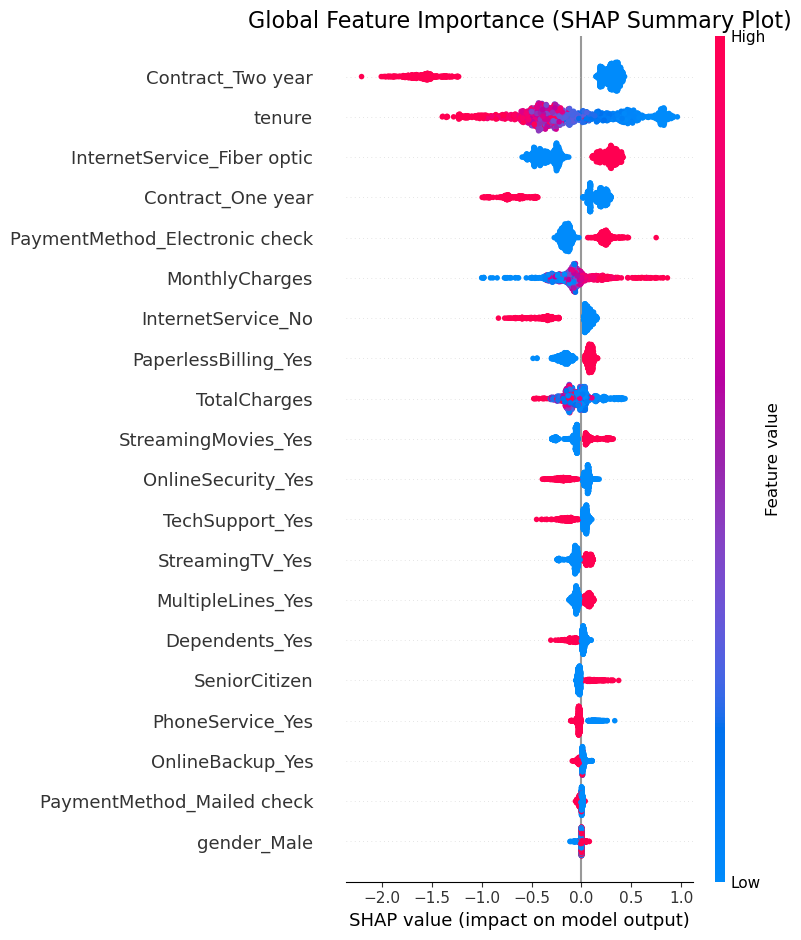

In [9]:
# Create a summary plot (Beeswarm plot)
plt.title("Global Feature Importance (SHAP Summary Plot)", fontsize=16)
shap.summary_plot(shap_values, X_test, plot_type="dot")

# 💡 BUSINESS INSIGHTS TO DOCUMENT IN YOUR README:
# 1. Tenure: The longest, blue dots (low tenure) stretch far to the right (positive SHAP value = high churn). This proves new customers are at the highest risk.
# 2. Contract_Two year: Pink dots (value = 1, meaning they have a 2-year contract) push heavily to the left (negative SHAP = retention). 
# 3. MonthlyCharges: Pink dots (high monthly charges) correlate with pushing the model to predict churn.

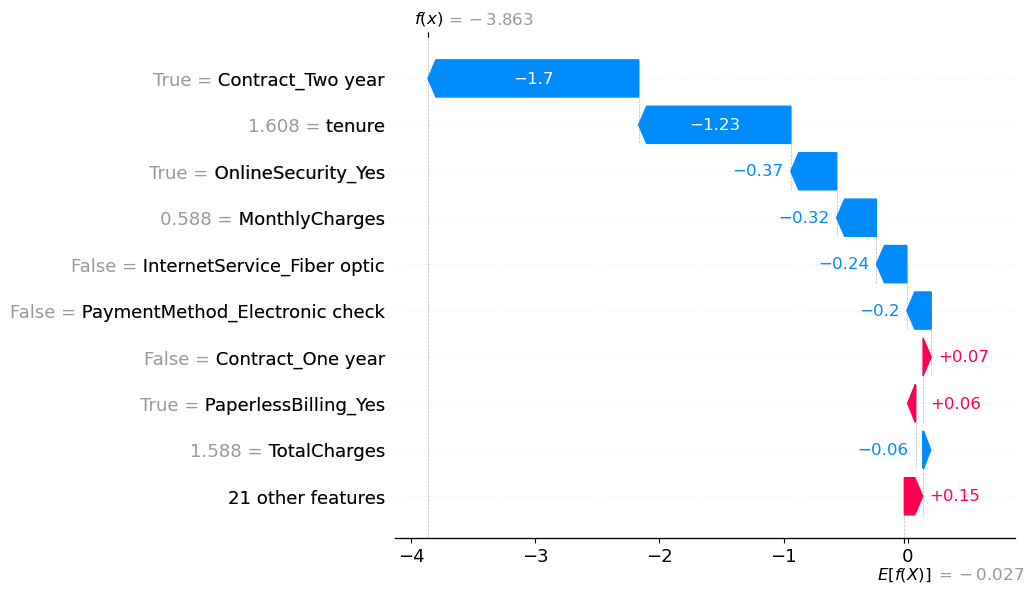

In [10]:
# Let's look at Customer #4 in our test set who is highly likely to churn
customer_index = 4

# Initialize the JS visualization for SHAP
shap.initjs()

# Create a waterfall plot for this specific customer
explainer_waterfall = shap.Explainer(model)
shap_values_waterfall = explainer_waterfall(X_test)

shap.plots.waterfall(shap_values_waterfall[customer_index])

# 💡 BUSINESS INSIGHT:
# This chart is perfect for a customer service dashboard. It shows exactly how a base probability 
# gets pushed higher (red) or lower (blue) by specific factors like this user's month-to-month contract.

### Business Strategy

- The First-90-Days Protocol: Because low tenure is the strongest driver of churn, the business must aggressively incentivize the first 3 months of the customer lifecycle (e.g., offering free onboarding support).

-Push for Annual Contracts: Month-to-month contracts strongly drive churn. We should offer a 15% discount for users who upgrade to a 1 or 2-year contract, locking in their Lifetime Value (LTV).

-Price Sensitivity: High MonthlyCharges trigger churn. The marketing team can use this model to identify customers with high monthly charges before they leave and send them a targeted $10 loyalty discount.